# Pnemoumonia Detection using Chest X-ray Images(CNN Implementation)

### 1. Data Acquisition
Acquiring data using Kagglehub API



In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


Importing required libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import seaborn as sns


### 2. Data Loading

Checking location of dataset

In [ ]:
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)

Contents of /kaggle/input/chest-xray-pneumonia:
chest-xray-pneumonia/
    chest_xray/
        chest_xray/
            val/
                PNEUMONIA/
                NORMAL/
            test/
                PNEUMONIA/
                NORMAL/
            train/
                PNEUMONIA/
                NORMAL/
        __MACOSX/
            chest_xray/
                val/
                    PNEUMONIA/
                    NORMAL/
                test/
                    PNEUMONIA/
                    NORMAL/
                train/
                    PNEUMONIA/
                    NORMAL/
        val/
            PNEUMONIA/
            NORMAL/
        test/
            PNEUMONIA/
            NORMAL/
        train/
            PNEUMONIA/
            NORMAL/


In [ ]:
base_dir = os.path.join(path, 'chest_xray', 'chest_xray')
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

print(f"Training data directory: {train_dir}")
print(f"Validation data directory: {val_dir}")
print(f"Test data directory: {test_dir}")

Training data directory: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
Validation data directory: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
Test data directory: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test


In [ ]:
for split_name, split_path in {
    "Training": train_dir,
    "Validation": val_dir,
    "Testing": test_dir
}.items():
    print(f"\n{split_name}:")
    if os.path.exists(split_path):
        # Filter out .DS_Store files
        filtered_list = [f for f in os.listdir(split_path) if f != '.DS_Store']
        print(filtered_list)
    else:
        print("Path not found. Please update DATASET_PATH.")


Training:
['PNEUMONIA', 'NORMAL']

Validation:
['PNEUMONIA', 'NORMAL']

Testing:
['PNEUMONIA', 'NORMAL']


In [ ]:
def count_images(directory):
    data = []
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            data.append({"class": class_name, "count": count})
    return pd.DataFrame(data)

train_count = count_images(train_dir)
val_count = count_images(val_dir)
test_count = count_images(test_dir)

display(train_count)
display(val_count)
display(test_count)

,class,count
0,NORMAL,1341
1,PNEUMONIA,3875


,class,count
0,NORMAL,8
1,PNEUMONIA,8


,class,count
0,NORMAL,234
1,PNEUMONIA,390


### 3. Data Augmentation and Input Pipeline Setup
All images are resized to a uniform dimension of 224×224 pixels to match the standard input expectation of downstream transfer learning architectures.

Data is shuffled and grouped into an optimized Batch Size of 32.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

print("Data augmentation pipeline created.")


Data augmentation pipeline created.


In [ ]:
image_shapes = []
for class_name in full_training_ds.class_names:
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
          print(f"Warning: Class directory not found: {class_path}")
          continue
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(tuple([".jpg", ".jpeg", ".png"]))
    ]

    for img_name in images[:50]: # Limit to 50 images per class for efficiency
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        image_shapes.append(img.size)

shape_df = pd.DataFrame(image_shapes, columns=["width", "height"])
display(shape_df.describe())

print("Unique Shapes:")
print(shape_df.value_counts().head())


,width,height
count,100.000000,100.000000
mean,1407.310000,1092.980000
std,342.925668,384.832982
min,703.000000,457.000000
25%,1140.000000,776.000000
50%,1396.000000,1103.500000
75%,1679.500000,1342.000000
max,2400.000000,2121.000000


Unique Shapes:
width  height
856    568       2
824    568       1
703    457       1
840    488       1
895    516       1
Name: count, dtype: int64


In [ ]:
full_training_ds = image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print(full_training_ds)


Found 5216 files belonging to 2 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>


In [ ]:
test_ds = image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(test_ds)


Found 624 files belonging to 2 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>


In [ ]:
val_ds_original = image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Original val_ds loaded from val_dir:", val_ds_original)


Found 16 files belonging to 2 classes.
Original val_ds loaded from val_dir: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>


### 4. Fixing Lack of Validation Data
In the original dataset validation set only contains 16 images. This small subset would lead to volatile validation metrics and poor model checkpoints. To fix this a subset of 5% of the training data is taken from the training dataset and added to the validation set

In [ ]:
val_size_from_train_batches = int(tf.data.experimental.cardinality(full_training_ds).numpy() * 0.05)
train_ds = full_training_ds.skip(val_size_from_train_batches)
val_ds_from_train = full_training_ds.take(val_size_from_train_batches)

val_ds = val_ds_from_train.concatenate(val_ds_original)

print(f"New train_ds (batches): {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches from training data: {tf.data.experimental.cardinality(val_ds_from_train).numpy()}")
print(f"Original validation batches from val_dir: {tf.data.experimental.cardinality(val_ds_original).numpy()}")
print(f"Combined val_ds (batches): {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Total batches in full_training_ds: {tf.data.experimental.cardinality(full_training_ds).numpy()}")


New train_ds (batches): 155
Validation batches from training data: 8
Original validation batches from val_dir: 1
Combined val_ds (batches): 9
Total batches in full_training_ds: 163


### 5. Transfer Learning via EfficientNetB0
Instead of training a CNN from scratch, which requires high computational cost and risk of overfitting, implementing transfer learning.
Model Archetype:

-Global Average Pooling 2D: Reduces spatial features down to a 1D vector while preserving structural information.

-Dense Layer (256 units, ReLU): Learns specific clinical abstractions from the extracted X-ray features.

-Dropout Layer (0.4): Randomly deactivates 40% of the neurons during training to prevent the network from memorizing the data (combating overfitting).

-Output Layer (1 unit, Sigmoid): Generates a continuous confidence value between 0.0 (Normal) and 1.0 (Pneumonia).

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Prefetch added.")


Prefetch added.


In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("Base model loaded.")
print("Trainable:", base_model.trainable)

Base model loaded.
Trainable: False


In [ ]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.4, name="dropout")(x)

outputs = layers.Dense(2, activation="softmax", name="output")(x)

model = models.Model(inputs, outputs, name="Pneumonia_Classifier")

model.summary()


Model: "Pneumonia_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,021 (16.70 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 6. Model Compilation and Callback
The Adam optimizer and binary crossentropy loss are used for this classification problem to achieve best results.

Callbacks Registered:

-ModelCheckpoint: Saves the best model from validation data training

-EarlyStopping: If validation fail to improve in 4 consecutive epochs training automatically stops to avoid overfitting

-ReduceLROnPlateau: Scales down learning rate if validation loss stalls for 2 epochs

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")


Model compiled.


In [ ]:
initial_learning_rate = 1e-3
fine_tune_learning_rate = 1e-5

print("Initial LR:", initial_learning_rate)
print("Fine Tune LR:", fine_tune_learning_rate)


Initial LR: 0.001
Fine Tune LR: 1e-05


In [ ]:
checkpoint_path = "/kaggle/working/best_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

print("Callbacks ready.")


Callbacks ready.


### 7. Model Training
The model is set to train for 15 epochs. Keeping a history of accuracy and loss in each epoch

In [ ]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8648 - loss: 0.2820
Epoch 1: val_accuracy improved from None to 0.91912, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 55s 275ms/step - accuracy: 0.9014 - loss: 0.2212 - val_accuracy: 0.9191 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 2/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9340 - loss: 0.1541
Epoch 2: val_accuracy improved from 0.91912 to 0.92279, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9393 - loss: 0.1517 - val_accuracy: 0.9228 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 3/15
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9425 - loss: 0.1383
Epoch 3: val_accuracy improved from 0.92279 to 0.95588, saving model to /kaggle/working/best_model.keras


### 8. Model Predictions
The model then predicts on the unseen test dataset.

In [ ]:
def get_predictions_and_labels(model, dataset):
    y_true = []
    y_pred_probs = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred_probs.extend(preds)
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_pred_probs = np.array(y_pred_probs)
    y_true = np.array(y_true)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return y_true, y_pred, y_pred_probs

In [ ]:
best_model = tf.keras.models.load_model(checkpoint_path)
val_true, val_pred, val_probs = get_predictions_and_labels(best_model, val_ds)

print("Validation Predictions Done")
print("Validation samples: ", len(val_true))

Validation Predictions Done
Validation samples:  272


In [ ]:
test_true, test_pred, test_probs = get_predictions_and_labels(best_model, test_ds)

print("Test Predictions Done")
print("Test samples:", len(test_true))

Test Predictions Done
Test samples: 624


### 9. Evaluation Metrics
The performance of the model is measured using comprehensive metrics to test the effectiveness of the model

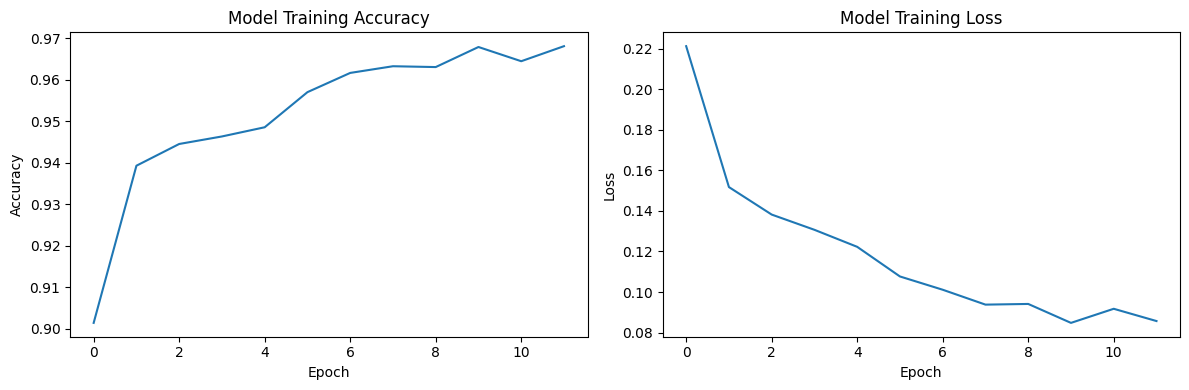

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

AUC-ROC Score: 0.9657


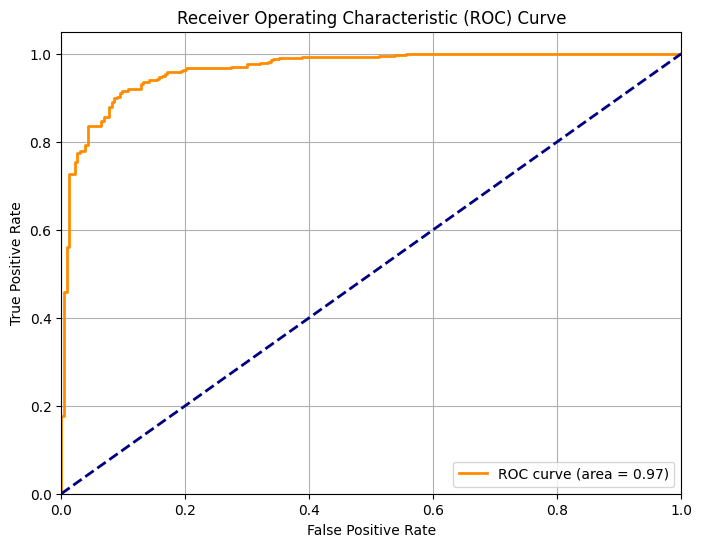

In [ ]:
fpr, tpr, thresholds = roc_curve(test_true, test_probs[:, 1])
roc_auc = auc(fpr, tpr)

print(f"AUC-ROC Score: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
dataset_class_names = ["NORMAL","PNEUMONIA"]

report = classification_report(
    test_true,
    test_pred,
    target_names=dataset_class_names
)

print(report)


              precision    recall  f1-score   support

      NORMAL       0.93      0.73      0.82       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



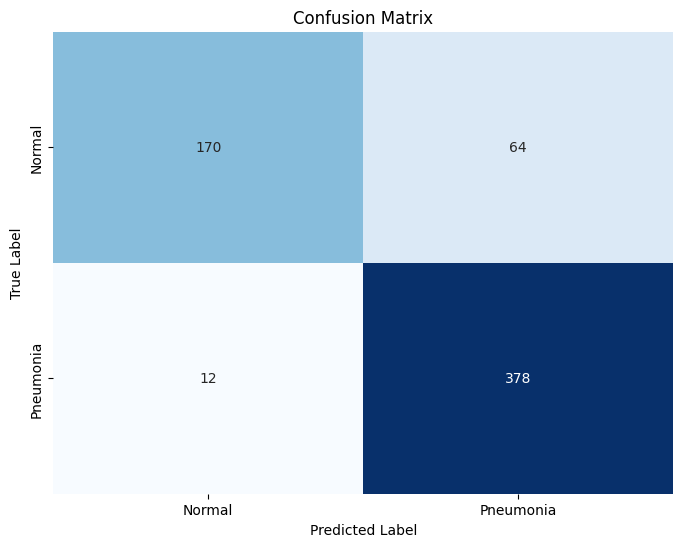

In [ ]:
cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=dataset_class_names, yticklabels=dataset_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 10. Targeted Error Analysis
Finding where the model fails

In [ ]:
def get_file_paths(directory):
    file_paths = []
    labels = []

    for idx, class_name in enumerate(dataset_class_names):
        class_path = os.path.join(directory, class_name)
        images = sorted([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        for img_name in images:
            file_paths.append(os.path.join(class_path, img_name))
            labels.append(idx)

    return file_paths, labels

test_file_paths, test_labels_from_paths = get_file_paths(test_dir)

misclassified_indices = np.where(test_true != test_pred)[0]
print("Total Misclassified Images:", len(misclassified_indices))


Total Misclassified Images: 76


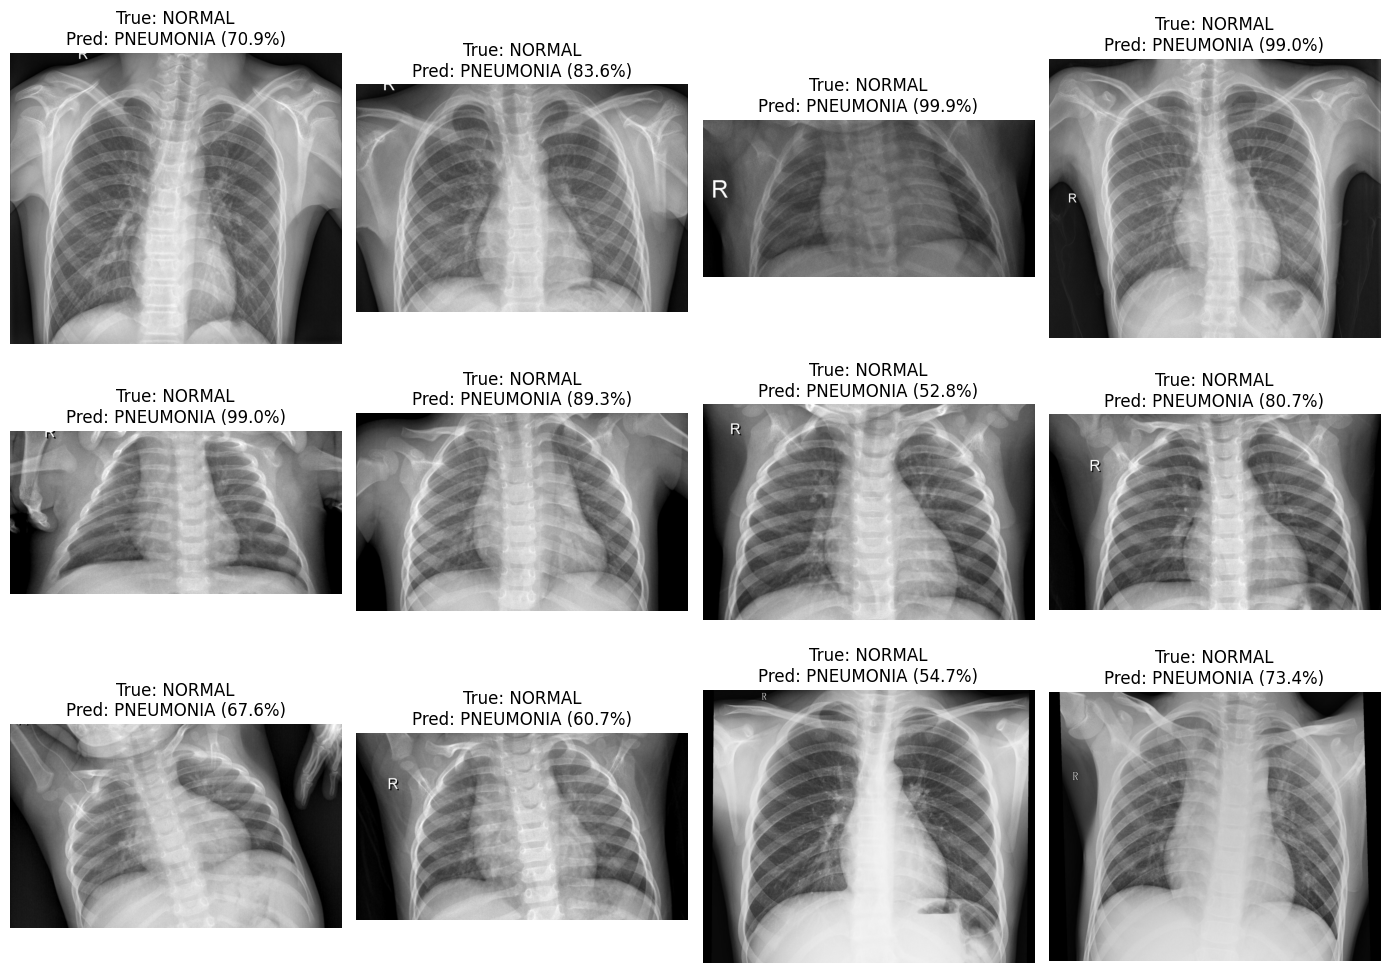

In [ ]:
plt.figure(figsize=(14, 10))

for i, idx in enumerate(misclassified_indices[:12]):
    img = Image.open(test_file_paths[idx]).convert("RGB")

    true_label = dataset_class_names[test_true[idx]]
    pred_label = dataset_class_names[test_pred[idx]]
    confidence = np.max(test_probs[idx]) * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 11. Explainable AI via Grad-CAM
To combat the blackbox problem and especially in a healthcare application Grad-Cam highlights the patterns recognized by the CNN

In [ ]:
def gradcam_for_efficientnet(full_model, img_path, class_names):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img)
    img_array_batch = np.expand_dims(img_array, axis=0)

    base = full_model.get_layer("efficientnetb0")

    grad_model = tf.keras.models.Model(
        inputs=base.inputs,
        outputs=[base.get_layer("top_conv").output, base.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = grad_model(img_array_batch)

        x = full_model.get_layer("global_average_pooling")(base_outputs)
        x = full_model.get_layer("dense_256")(x)
        x = full_model.get_layer("dropout")(x, training=False)
        preds = full_model.get_layer("output")(x)

        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) != 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return img, heatmap.numpy(), preds.numpy()[0]


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


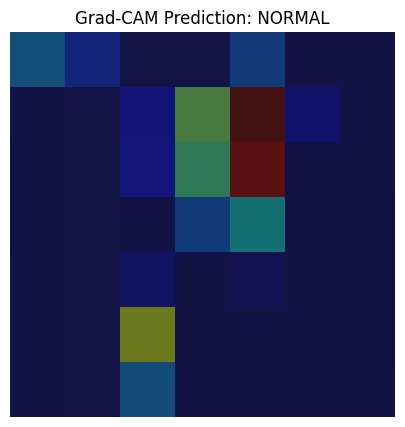

In [ ]:
sample_img_path = test_file_paths[0]

img, heatmap, preds = gradcam_for_efficientnet(best_model, sample_img_path, dataset_class_names)

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.imshow(heatmap, alpha=0.4, cmap="jet")
plt.title(f"Grad-CAM Prediction: {dataset_class_names[np.argmax(preds)]}")
plt.axis("off")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


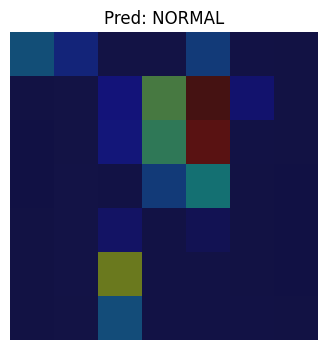

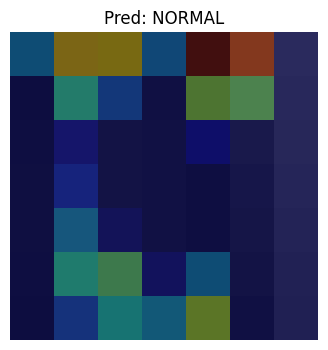

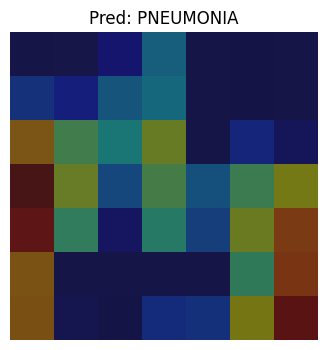

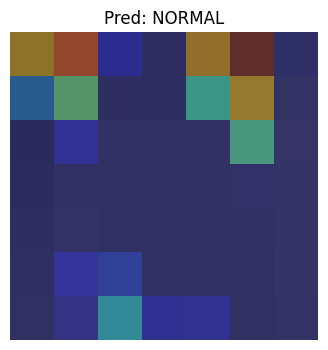

In [ ]:
for idx in range(min(4, len(test_file_paths))):
    img, heatmap, preds = gradcam_for_efficientnet(best_model, test_file_paths[idx], dataset_class_names)

    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.imshow(heatmap, alpha=0.4, cmap="jet")
    plt.title(f"Pred: {dataset_class_names[np.argmax(preds)]}")
    plt.axis("off")
    plt.show()

### 12. Export Model

In [ ]:
export_dir = "/kaggle/working/Pneumonia_detection_model"
best_model.export(export_dir)

print("SavedModel exported at:", export_dir)

class_names_path = "/kaggle/working/class_names.txt"

with open(class_names_path, "w") as f:
    for name in dataset_class_names:
        f.write(name + "\n")

print("Class names saved at:", class_names_path)

Saved artifact at '/kaggle/working/Pneumonia_detection_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133584355661904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133584355670160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133584355669200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133584355663056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133581295963024: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133581295966096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133584355669392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133584355668816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133584355667856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133584355666128: TensorSpec(shape=(), dt